In [1]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
img_path = r"C:\CS2441\satellite_images\SENTINEL 2\GRANULE\L2A_T44QLJ_A008426_20260417T051527\IMG_DATA\R10m"

In [3]:
b02_path = os.path.join(img_path, "T44QLJ_20260417T050651_B02_10m.jp2")

with rasterio.open(b02_path) as src:
    blue = src.read(1)

In [4]:
b03_path = os.path.join(img_path, "T44QLJ_20260417T050651_B03_10m.jp2" )

with rasterio.open(b03_path) as src:
    green = src.read(1)

In [5]:
b04_path = os.path.join(img_path, "T44QLJ_20260417T050651_B04_10m.jp2")

with rasterio.open(b04_path) as src:
    red = src.read(1)

In [6]:
b08_path = os.path.join(img_path, "T44QLJ_20260417T050651_B08_10m.jp2")

with rasterio.open(b08_path) as src:
    nir = src.read(1)

In [7]:
print("all bands are loaded sucessfully!")

all bands are loaded sucessfully!


In [8]:
print("Blue Band (b02):")
print("shape : ", blue.shape)
print("Data Type : ", blue.dtype)
print("Min : ", blue.min())
print("Max : ", blue.max()) 
print("Mean : ", round(blue.mean(), 2))

Blue Band (b02):
shape :  (10980, 10980)
Data Type :  uint16
Min :  0
Max :  27172
Mean :  1847.13


In [9]:
print("Green Band (b03):")
print("Shape : ", green.shape)
print("Data Type : ", green.dtype)
print("Min : ", green.min())
print("Max : ", green.max())
print("Mean : ", round(green.mean(), 2))

Green Band (b03):
Shape :  (10980, 10980)
Data Type :  uint16
Min :  1054
Max :  23988
Mean :  2111.54


In [10]:
print("Red Band (b04):")
print("Shape : ", red.shape)
print("Data Type : ", red.dtype)
print("Min : ", red.min())
print("Max : ", red.max())
print("Mean : ", round(red.mean(), 2))

Red Band (b04):
Shape :  (10980, 10980)
Data Type :  uint16
Min :  0
Max :  19379
Mean :  2325.36


In [11]:
print("NIR Band (b08):")
print("Shape : ", nir.shape)
print("Data Type : ", nir.dtype)
print("Min : ", nir.min())
print("Max : ", nir.max())
print("Mean : ", round(nir.mean(), 2))

NIR Band (b08):
Shape :  (10980, 10980)
Data Type :  uint16
Min :  0
Max :  19320
Mean :  3415.09


In [12]:
with rasterio.open(b02_path) as src:
    print("Image Metadata")
    print("Driver : ", src.driver)
    print("Width : ", src.width)
    print("Height : ", src.height)
    print("N.o of bands : ", src.count)
    print("Data Type : ", src.dtypes)
    print("CRS : ", src.crs)
    print("Transform : ", src.transform)

Image Metadata
Driver :  JP2OpenJPEG
Width :  10980
Height :  10980
N.o of bands :  1
Data Type :  ('uint16',)
CRS :  EPSG:32644
Transform :  | 10.00, 0.00, 300000.00|
| 0.00,-10.00, 2400000.00|
| 0.00, 0.00, 1.00|


In [13]:
with rasterio.open(b02_path) as src:
    res = src.res
    print("Spatial Resoulution")
    print("Pixel Resolution : ", res)
    print("Each Pixel Covers : ", res[0], "meters x", res[1], "meters")

Spatial Resoulution
Pixel Resolution :  (10.0, 10.0)
Each Pixel Covers :  10.0 meters x 10.0 meters


In [14]:
with rasterio.open(b02_path) as src:
    bounds = src.bounds
    print("Bounding Box")
    print("Left (West) :", bounds.left)
    print("Right (East) :", bounds.right)
    print("Top (North) :", bounds.top)
    print("Bottom (South) :", bounds.bottom)

Bounding Box
Left (West) : 300000.0
Right (East) : 409800.0
Top (North) : 2400000.0
Bottom (South) : 2290200.0


In [15]:
with rasterio.open(b02_path) as src:
    print("NoData Value:", src.nodata)

NoData Value: None


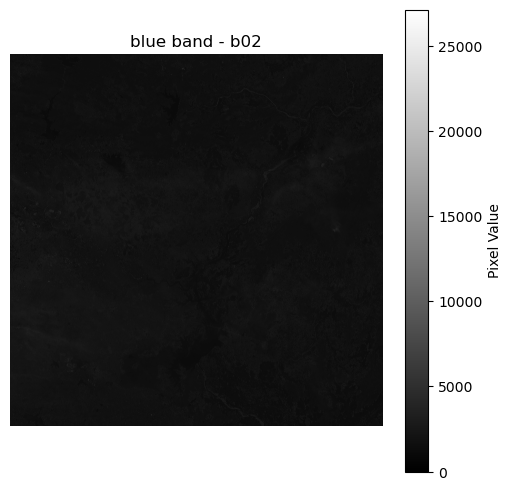

In [16]:
plt.figure(figsize=(6,6))
plt.imshow(blue, cmap='gray')
plt.title('blue band - b02')
plt.colorbar(label='Pixel Value')
plt.axis('off')
plt.show()

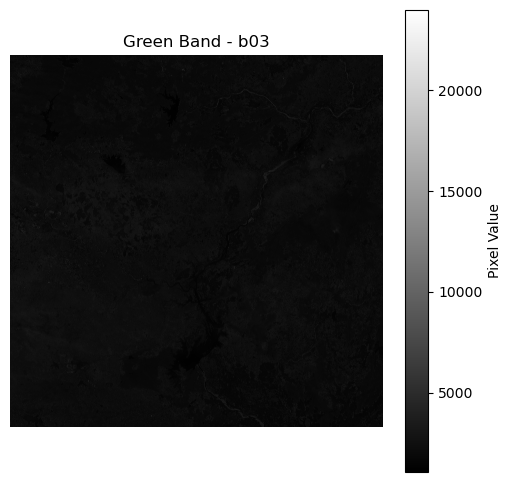

In [19]:
plt.figure(figsize=(6,6))
plt.imshow(green, cmap='gray')
plt.title('Green Band - b03')
plt.colorbar(label='Pixel Value')
plt.axis('off')
plt.show()

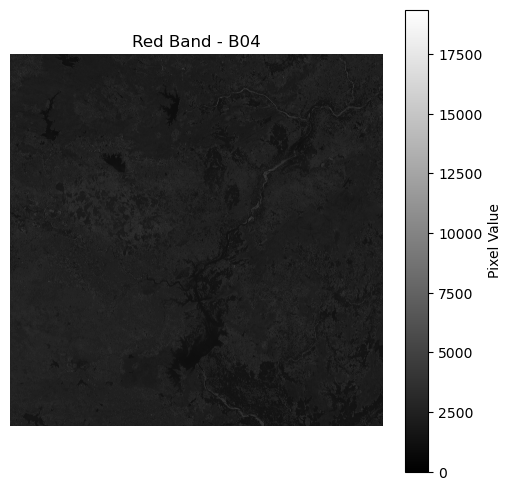

In [20]:
plt.figure(figsize=(6,6))
plt.imshow(red, cmap='gray')
plt.title('Red Band - B04')
plt.colorbar(label='Pixel Value')
plt.axis('off')
plt.show()

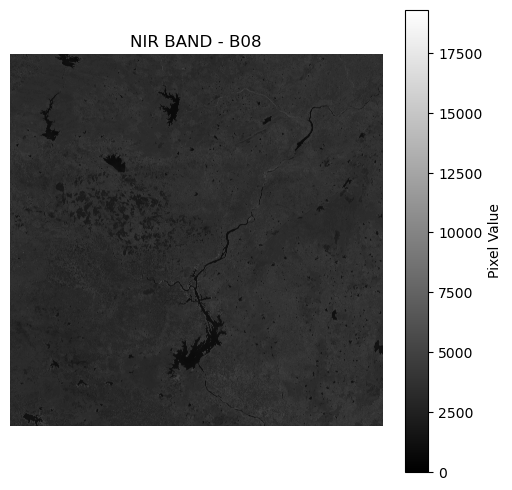

In [21]:
plt.figure(figsize=(6,6))
plt.imshow(nir, cmap='gray')
plt.title('NIR BAND - B08')
plt.colorbar(label='Pixel Value')
plt.axis('off')
plt.show()

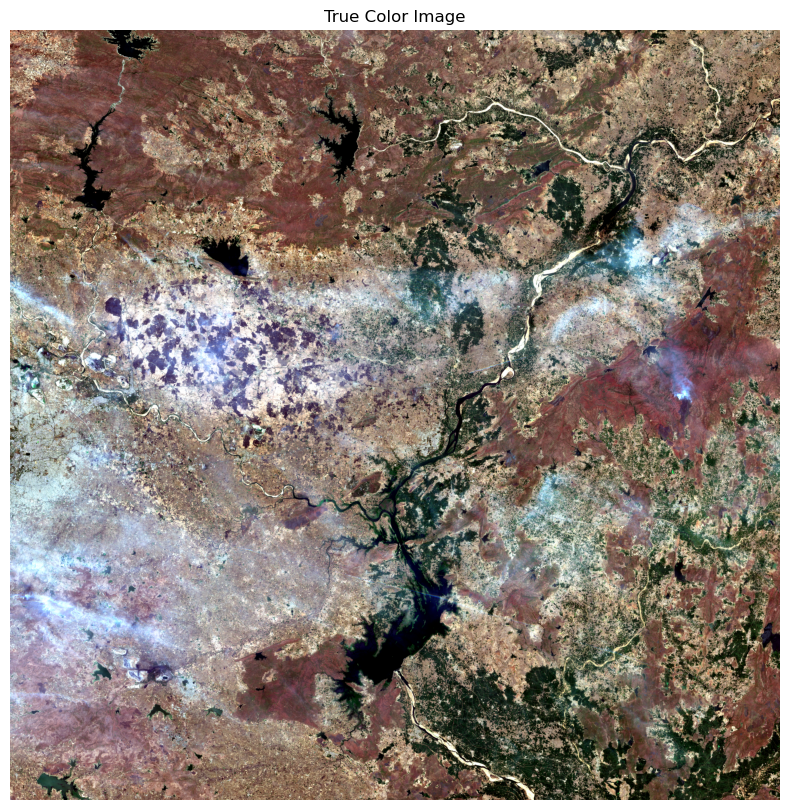

In [77]:
def normalize_percentile(band, low=2, high=98):
    p_low = np.percentile(band, low)
    p_high = np.percentile(band, high)
    clipped = np.clip(band, p_low, p_high)
    return (clipped - p_low) / (p_high - p_low)

true_color = np.dstack((normalize_percentile(red),   
                        normalize_percentile(green),  
                        normalize_percentile(blue))) 

true_color_uint8 = (true_color * 255).astype(np.uint8)

plt.figure(figsize=(10, 10))
plt.imshow(true_color)
plt.title('True Color Image')
plt.axis('off')
plt.show()

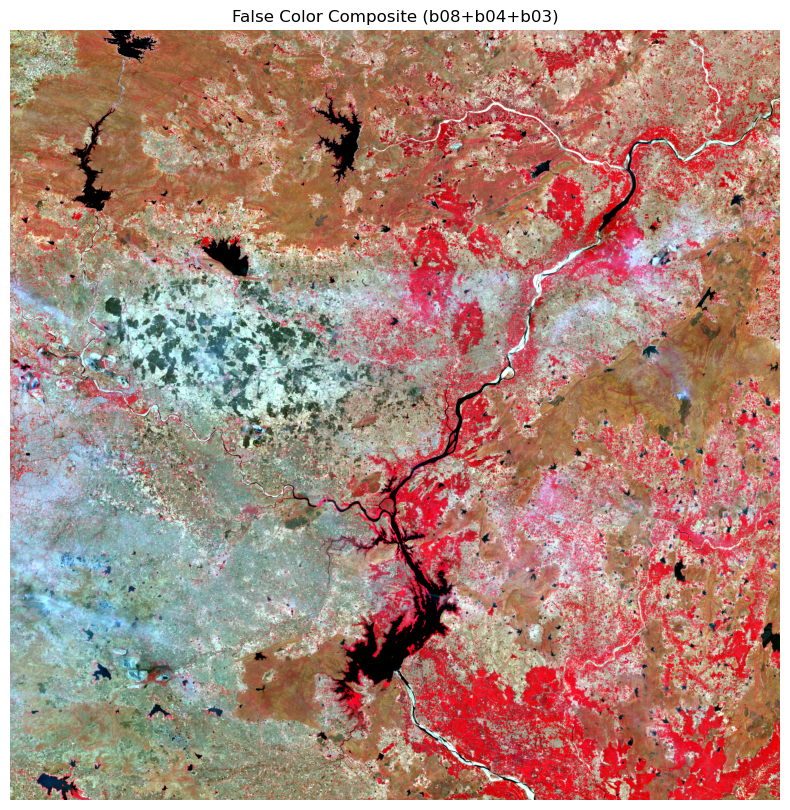

In [23]:
def normalize_percentile(band, low=2, high=98):
    p_low  = np.percentile(band, low)
    p_high = np.percentile(band, high)
    clipped = np.clip(band, p_low, p_high)
    return (clipped - p_low) / (p_high - p_low)

false_color = np.dstack((normalize_percentile(nir),
                         normalize_percentile(red),
                         normalize_percentile(green)))
plt.figure(figsize=(10,10))
plt.imshow(false_color)
plt.title('False Color Composite (b08+b04+b03)')
plt.axis('off')
plt.show()

In [24]:
green_f = green.astype(float)
nir_f = nir.astype(float)
ndwi = (green_f - nir_f) / (green_f + nir_f)

In [25]:
print("min :", round(ndwi.min(), 4))
print("max :", round(ndwi.max(), 4))
print("mean :", round(ndwi.mean(), 4))

min : -0.7119
max : 1.0
mean : -0.2295


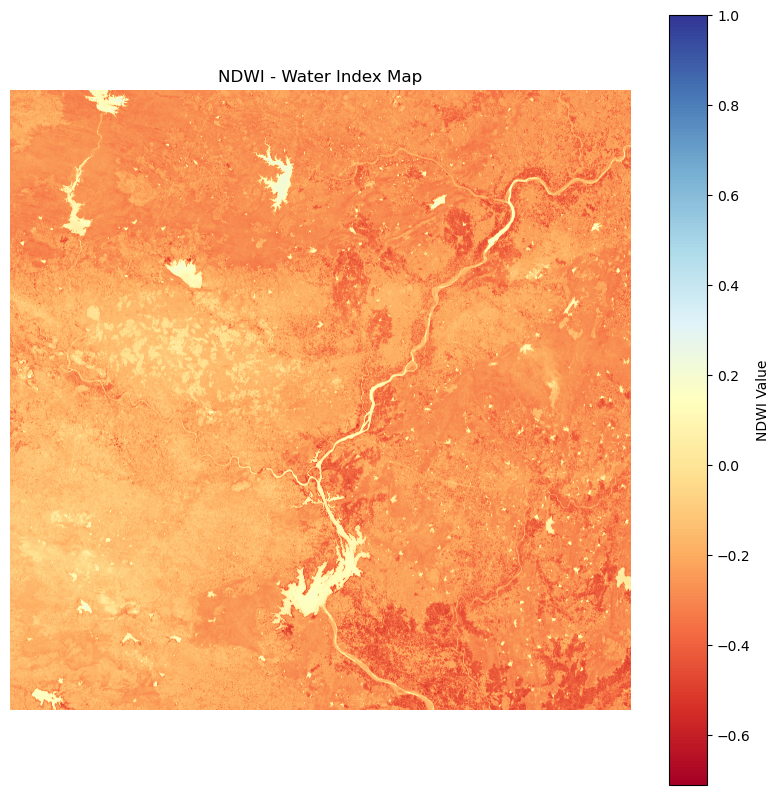

In [26]:
plt.figure(figsize = (10,10))
plt.imshow(ndwi, cmap='RdYlBu')
plt.colorbar(label='NDWI Value')
plt.title('NDWI - Water Index Map')
plt.axis('off')
plt.show()

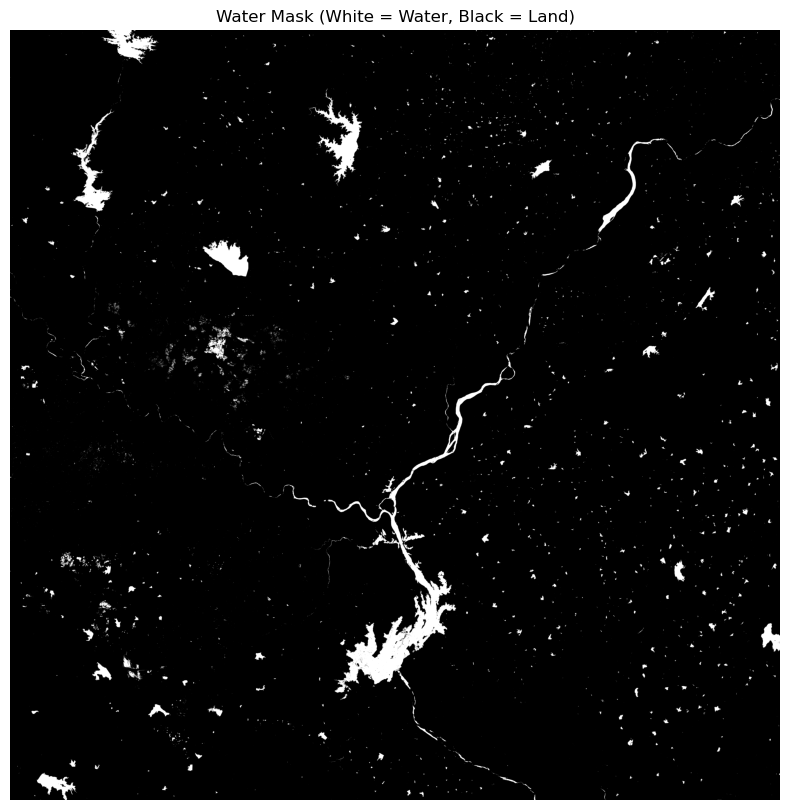

In [60]:
water_mask = ndwi > 0

water_mask_display = np.where(water_mask, 255, 0).astype(np.uint8)

plt.figure(figsize=(10,10))
plt.imshow(water_mask_display, cmap='gray')
plt.title('Water Mask (White = Water, Black = Land)')
plt.axis('off')
plt.show()

In [62]:
water_pixels = np.sum(water_mask)
total_pixels = water_mask.size
land_pixels = total_pixels - water_pixels

print("Total Pixels :", total_pixels)
print("Water Pixels :", water_pixels)
print("Land Pixels :", land_pixels)

Total Pixels : 120560400
Water Pixels : 3217156
Land Pixels : 117343244


In [64]:
pixel_area_m2 = 10 * 10
pixel_area_km2 = pixel_area_m2 / 1_000_000

water_area_m2 = water_pixels*pixel_area_m2
water_area_km2 = water_pixels * pixel_area_km2
total_area_km2 = total_pixels * pixel_area_km2

print("Total Image Area :", round(total_area_km2, 2), "km²")
print("Water Area       :", round(water_area_km2, 2), "km²")
print("Water Coverage   :", round((water_area_km2 / total_area_km2) * 100, 2), "%")

Total Image Area : 12056.04 km²
Water Area       : 321.72 km²
Water Coverage   : 2.67 %


In [66]:
import os
from PIL import Image

# Create results folder
results_path = r"C:\CS2441\satellite_images\analysis_results"
os.makedirs(results_path, exist_ok=True)
print("analysis_results folder created!")

analysis_results folder created!


In [70]:
true_color_uint8 = (true_color * 255).astype(np.uint8)
print("true_color_uint8 shape:", true_color_uint8.shape)
print("✅ Converted successfully!")

true_color_uint8 shape: (10980, 10980, 3)
✅ Converted successfully!


In [81]:
import rasterio
from rasterio.transform import from_bounds

with rasterio.open(b02_path) as src:
    transform = src.transform
    crs       = src.crs
    profile   = src.profile

profile.update(
    dtype  = rasterio.uint8,
    count  = 1,
    driver = 'GTiff'
)

mask_tif_path = os.path.join(results_path, "water_mask.tif")
with rasterio.open(mask_tif_path, 'w', **profile) as dst:
    dst.write(water_mask_display, 1)
print("Water mask saved as GeoTIFF!")

profile.update(count=3)
true_tif_path = os.path.join(results_path, "true_color.tif")
with rasterio.open(true_tif_path, 'w', **profile) as dst:
    dst.write(true_color_uint8[:,:,0], 1)  # Red
    dst.write(true_color_uint8[:,:,1], 2)  # Green
    dst.write(true_color_uint8[:,:,2], 3)  # Blue
print("True color saved as GeoTIFF!")

false_color_uint8 = (false_color * 255).astype(np.uint8)
false_tif_path = os.path.join(results_path, "false_color.tif")
with rasterio.open(false_tif_path, 'w', **profile) as dst:
    dst.write(false_color_uint8[:,:,0], 1)
    dst.write(false_color_uint8[:,:,1], 2)
    dst.write(false_color_uint8[:,:,2], 3)
print("False color saved as GeoTIFF!")

print("\n=== All files saved to ===")
print(results_path)

Water mask saved as GeoTIFF!
True color saved as GeoTIFF!
False color saved as GeoTIFF!

=== All files saved to ===
C:\CS2441\satellite_images\analysis_results


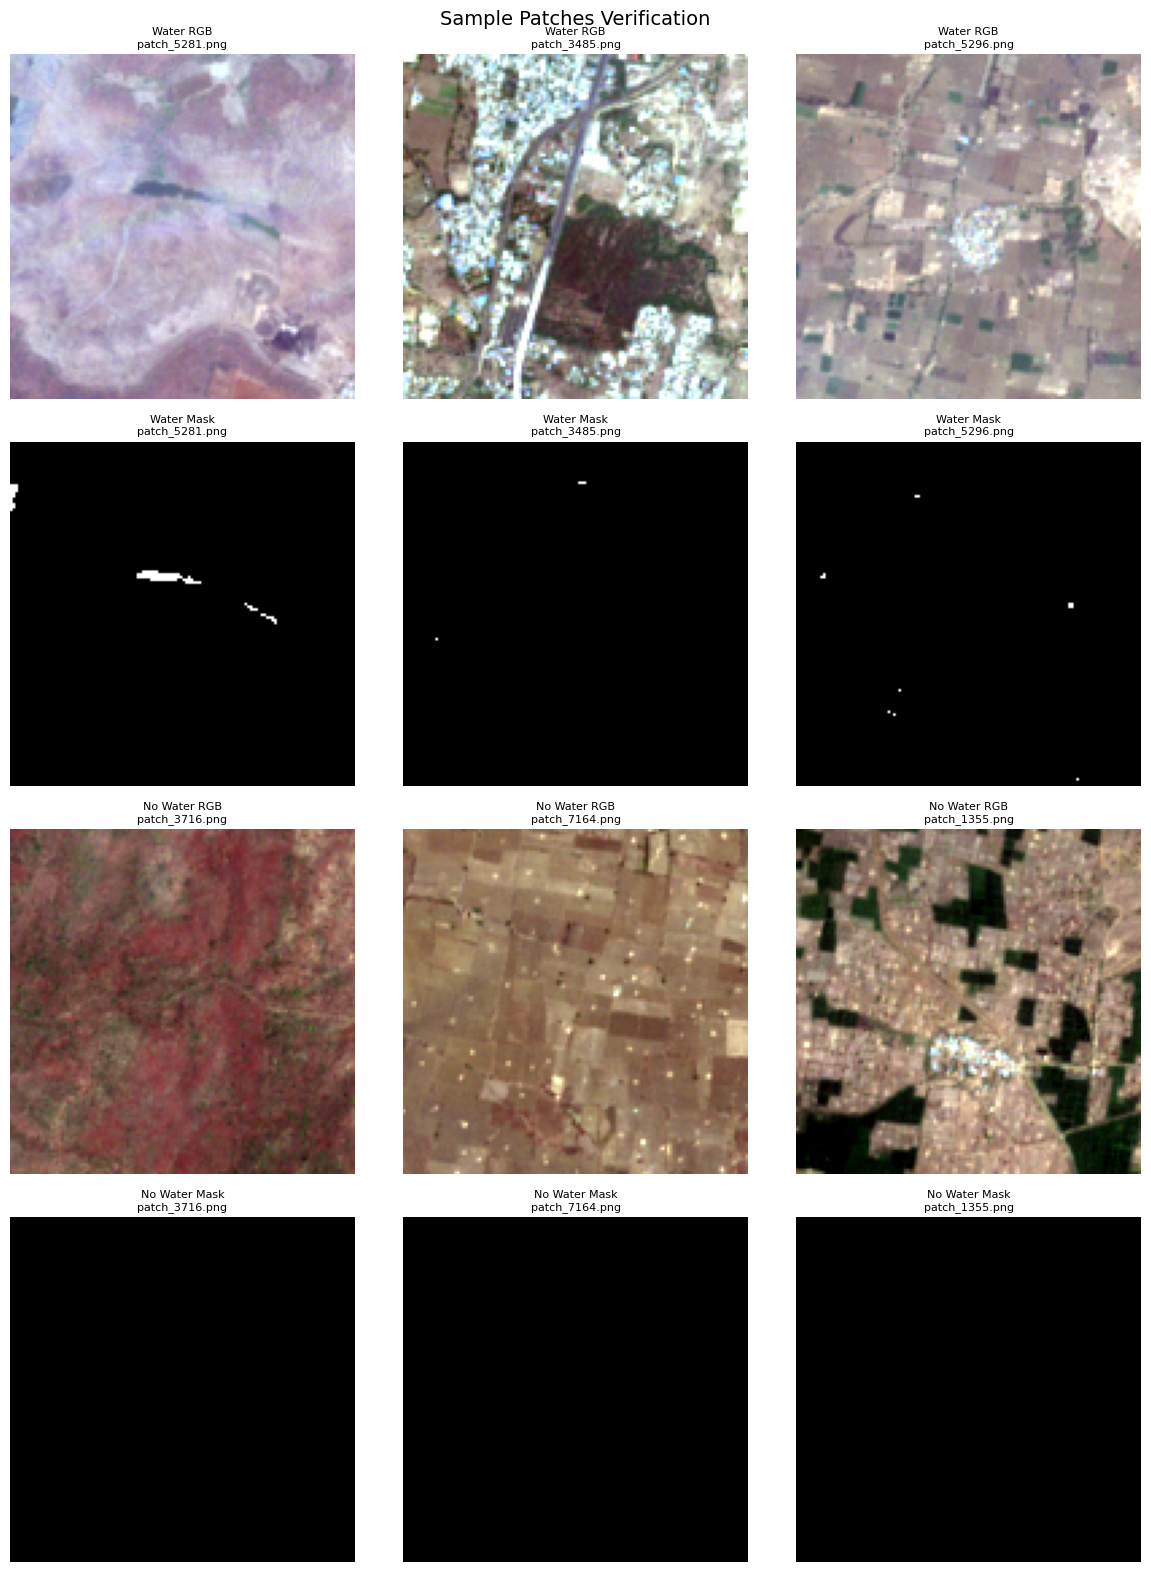

In [83]:
import random
from PIL import Image
import matplotlib.pyplot as plt

water_rgb_path    = r"C:\CS2441\satellite_images\patches\water\rgb"
water_mask_path   = r"C:\CS2441\satellite_images\patches\water\mask"
nowat_rgb_path    = r"C:\CS2441\satellite_images\patches\no_water\rgb"
nowat_mask_path   = r"C:\CS2441\satellite_images\patches\no_water\mask"

water_files = random.sample(os.listdir(water_rgb_path), 3)

nowat_files = random.sample(os.listdir(nowat_rgb_path), 3)

fig, axes = plt.subplots(4, 3, figsize=(12, 16))

for i, fname in enumerate(water_files):
    img = Image.open(os.path.join(water_rgb_path, fname))
    axes[0, i].imshow(img)
    axes[0, i].set_title(f'Water RGB\n{fname}', fontsize=8)
    axes[0, i].axis('off')

for i, fname in enumerate(water_files):
    img = Image.open(os.path.join(water_mask_path, fname))
    axes[1, i].imshow(img, cmap='gray')
    axes[1, i].set_title(f'Water Mask\n{fname}', fontsize=8)
    axes[1, i].axis('off')

for i, fname in enumerate(nowat_files):
    img = Image.open(os.path.join(nowat_rgb_path, fname))
    axes[2, i].imshow(img)
    axes[2, i].set_title(f'No Water RGB\n{fname}', fontsize=8)
    axes[2, i].axis('off')

for i, fname in enumerate(nowat_files):
    img = Image.open(os.path.join(nowat_mask_path, fname))
    axes[3, i].imshow(img, cmap='gray')
    axes[3, i].set_title(f'No Water Mask\n{fname}', fontsize=8)
    axes[3, i].axis('off')

plt.suptitle('Sample Patches Verification', fontsize=14)
plt.tight_layout()
plt.show()